# 04. PyTorch custom Datasets

Get your own datasets

## Domain libraries

Check in which categories belongs your data : torchvision, torchaudio...

## Ajout des images dans le bon fichier


In [ ]:
import requests
import zipfile
from pathlib import Path


# Setup train and testing path
train_dir =  "drive/MyDrive/artishow/Dataset/train"
test_dir =  "drive/MyDrive/artishow/Dataset/test"

## 7. Model 0: TinyVGG  without data augmentation

Let's replicaite the TinyVGG architecture from the CNN Explainer

In [ ]:
from torch import nn
import torch

class TinyVGG(nn.Module):
  """Creates the TinyVGG architecture.

  Replicates the TinyVGG architecture from the CNN explainer"""

  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(nn.Conv2d(in_channels=input_shape,
                                                out_channels = hidden_units,
                                                kernel_size=3,
                                                stride = 1,
                                                padding =0
                                                ),
                                      nn.ReLU(),
                                      nn.Conv2d(in_channels = hidden_units,
                                                out_channels = hidden_units,
                                                kernel_size = 3,
                                                stride = 1,
                                                padding = 0),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size=2,
                                                   stride=2) # default stride value is same as kernel_size
                                      )
    self.conv_block_2 = nn.Sequential(nn.Conv2d(in_channels=hidden_units,
                                                out_channels = hidden_units,
                                                kernel_size=3,
                                                stride = 1,
                                                padding =0
                                                ),
                                      nn.ReLU(),
                                      nn.Conv2d(in_channels = hidden_units,
                                                out_channels = hidden_units,
                                                kernel_size = 3,
                                                stride = 1,
                                                padding = 0),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size=2,
                                                   stride=2)
                                      )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*13*13,
                  out_features=output_shape)
    )
  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x # or we can use fusion, benefits from operator fusion (f(y(x)))

### 7.1 Creating transforms and loading data for Model 0


In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"


## 9. Model 1: TinyVGG with data augmentation

Same model but some data augmentation

### 9.1 Create transform with data augmentation

In [ ]:
# Create training transform with TrivialAugment
from torchvision import transforms

train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64,64)),
    #transforms.TrivialAugmentWide(num_magnitude_bins =31),
    transforms.ToTensor()
])

# Create testing transform
test_transform_simple = transforms.Compose([transforms.Resize(size=(64,64)),
                                            transforms.ToTensor()])



### 9.2 Create train and `dataset`'s and `DataLoader`'s with data augmentation

In [ ]:
# Turn image folders into Datasets
from torchvision import datasets

train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform=train_transform_trivial,
                                            )

test_data_simple = datasets.ImageFolder(root=test_dir,
                                            transform=test_transform_simple,
                                            )

In [ ]:
X, y = next(iter(train_dataloader_augmented))
print("X:", X.shape)
print("y:", y)
print("y shape:", y.shape)
print("unique labels:", y.unique())

X: torch.Size([12, 3, 64, 64])
y: tensor([10, 10,  8,  6,  4, 10,  8,  4,  6, 10, 10,  2])
y shape: torch.Size([12])
unique labels: tensor([ 2,  4,  6,  8, 10])


In [ ]:
# Turn our Datasets into DataLoader
import os
import torch
from torch.utils.data import DataLoader

# Setup batch size and number of workers
BATCH_SIZE = 12
NUM_WORKERS = os.cpu_count()


train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)


In [ ]:
train_data_augmented.classes


['Atelectasis',
 'Calcified Granuloma',
 'Cardiomegaly',
 'Edema',
 'Effusion',
 'Emphysema',
 'Granuloma',
 'Infiltration',
 'Lung Opacity',
 'Nodule',
 'Normal',
 'Pneumonia']

### 9.3 Construct and train model 1


In [ ]:
# Create model_1 and send it to the target device

model_1 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)
).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=12, bias=True)
  )
)

In [ ]:
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device = device):

  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader data batches
  for batch, (X, y) in enumerate(dataloader):
    # Send to the target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate the loss


    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate accuracy metric
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust metrics to get average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [ ]:
# Create a test step
def test_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               device: torch.device = device
               ):

  # Put the model in eval mode
  model.eval()

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference mode
  with torch.inference_mode():
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
      # Send to the target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X)

      # 2. Calculate the loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Calculate accuracy metric
      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += (test_pred_labels == y).sum().item()/len(test_pred_labels)

  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

In [ ]:
from tqdm.auto import tqdm

# 1. Create a train function that takes in various model parameters + optimize + data loader + loss_function
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device = device):
  # 2. Create empty results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}
  # 3. Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader= train_dataloader,
                                       loss_fn = loss_fn,
                                       optimizer=optimizer,
                                       device = device)
    test_loss, test_acc = test_step(model=model,
                                       dataloader= test_dataloader,
                                       loss_fn = loss_fn,
                                       device =device)
    # 4. Print out what's happening
    print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

    # 5. Update results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # 6. Return the filled results at the end of the epochs
  return results


In [ ]:

# Set the number of epochs
NUM_EPOCHS = 5

# Setup loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                         lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model 1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

### 9.4 Plot the loss curves of model_1

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
  """Plots training curves of a results dictionary.
  """
  # Get the loss values of the results dictionary(training and test)
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  # Get the accuracy values of the results dictionary (training and test)
  acc = results["train_acc"]
  test_acc = results["test_acc"]

  # Figure out how many epochs there were
  epochs = range(len(results["train_loss"]))

  # Setup a plot
  plt.figure(figsize=(15,7))

  # Plot the loss
  plt.subplot(1,2,1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  # Plot the accuracy
  plt.subplot(1,2,2)
  plt.plot(epochs, acc, label="train_acc")
  plt.plot(epochs, test_acc, label="test_acc")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend();

NameError: name 'Dict' is not defined

In [ ]:
plot_loss_curves(model_1_results)

## 11.1 Loading in a custom with PyTorch

We have to make sure our custom image is in the same format as the data our model was trained on.
* In tensor form with datatype (torch.float32)
* Of shape 64x64x3
* On the right device


In [ ]:
import torchvision

# Read custom image
custom_image_uint8 = torchvision.io.read_image("drive/MyDrive/artishow/Dataset/test/Atelectasis/CXR1053_IM-0040-3003.png")
print(f"Custom image Tensor: {custom_image_uint8}")
print(f"Custom image shape: {custom_image_uint8.shape}")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image Tensor: tensor([[[ 9,  9,  9,  ..., 51, 47, 41],
         [ 9,  9,  9,  ..., 50, 46, 40],
         [ 9,  9,  9,  ..., 49, 45, 39],
         ...,
         [73, 74, 76,  ...,  3,  3,  3],
         [74, 75, 77,  ...,  3,  3,  3],
         [75, 76, 78,  ...,  3,  3,  3]],

        [[ 9,  9,  9,  ..., 51, 47, 41],
         [ 9,  9,  9,  ..., 50, 46, 40],
         [ 9,  9,  9,  ..., 49, 45, 39],
         ...,
         [73, 74, 76,  ...,  3,  3,  3],
         [74, 75, 77,  ...,  3,  3,  3],
         [75, 76, 78,  ...,  3,  3,  3]],

        [[ 9,  9,  9,  ..., 51, 47, 41],
         [ 9,  9,  9,  ..., 50, 46, 40],
         [ 9,  9,  9,  ..., 49, 45, 39],
         ...,
         [73, 74, 76,  ...,  3,  3,  3],
         [74, 75, 77,  ...,  3,  3,  3],
         [75, 76, 78,  ...,  3,  3,  3]]], dtype=torch.uint8)
Custom image shape: torch.Size([3, 624, 512])
Custom image dtype: torch.uint8


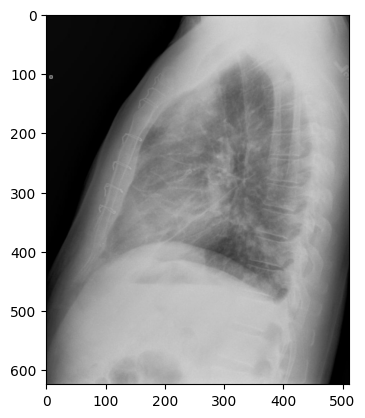

In [ ]:
plt.imshow(custom_image_uint8.permute(1,2,0));

### 11.2 Making a prediciton on a custom image with a trained PyTorch model

In [ ]:
import torchvision
custom_image_path ="drive/MyDrive/artishow/Dataset/test/Atelectasis/CXR1053_IM-0040-3003.png"
# Load in the custom image an convert to torch.float32
custom_image = torchvision.io.read_image("drive/MyDrive/artishow/Dataset/test/Atelectasis/CXR1053_IM-0040-3003.png").type(torch.float32)/255 # Value between zero and one like our trained images

In [ ]:
# Create transform pipeline to resize image
from torchvision import transforms
custom_image_transform = transforms.Compose([
    transforms.Resize(size=(64,64))])

# Tansform target image
custom_image_transformed = custom_image_transform(custom_image)

# Print out the shape
print(f"Original shape: {custom_image.shape}")
print(f"Custom image shape: {custom_image_transformed.shape}")


Original shape: torch.Size([3, 624, 512])
Custom image shape: torch.Size([3, 64, 64])


In [ ]:
custom_image_transformed.shape

torch.Size([3, 64, 64])

In [ ]:
custom_image_uint8

tensor([[[ 9,  9,  9,  ..., 51, 47, 41],
         [ 9,  9,  9,  ..., 50, 46, 40],
         [ 9,  9,  9,  ..., 49, 45, 39],
         ...,
         [73, 74, 76,  ...,  3,  3,  3],
         [74, 75, 77,  ...,  3,  3,  3],
         [75, 76, 78,  ...,  3,  3,  3]],

        [[ 9,  9,  9,  ..., 51, 47, 41],
         [ 9,  9,  9,  ..., 50, 46, 40],
         [ 9,  9,  9,  ..., 49, 45, 39],
         ...,
         [73, 74, 76,  ...,  3,  3,  3],
         [74, 75, 77,  ...,  3,  3,  3],
         [75, 76, 78,  ...,  3,  3,  3]],

        [[ 9,  9,  9,  ..., 51, 47, 41],
         [ 9,  9,  9,  ..., 50, 46, 40],
         [ 9,  9,  9,  ..., 49, 45, 39],
         ...,
         [73, 74, 76,  ...,  3,  3,  3],
         [74, 75, 77,  ...,  3,  3,  3],
         [75, 76, 78,  ...,  3,  3,  3]]], dtype=torch.uint8)

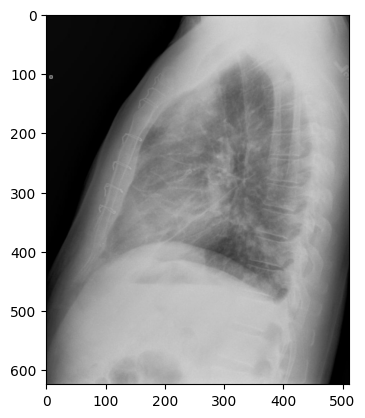

In [ ]:
plt.imshow(custom_image.permute(1,2,0));

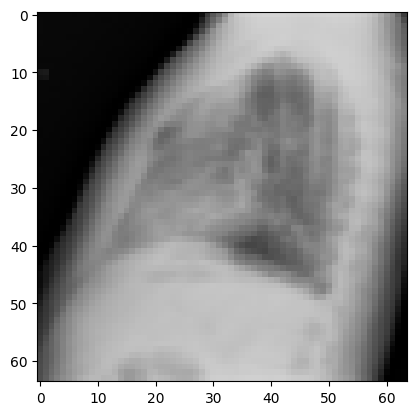

In [ ]:
plt.imshow(custom_image_transformed.permute(1,2,0));

In [ ]:
# Try to make a prediction on an image in uint8 format
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device)) # Batch size ((0) : on the first dimension) and same device
custom_image_pred

tensor([[-0.5247, -0.6177, -0.7184, -1.9165, -1.5910, -1.0927, -0.0334, -1.9201,
          0.0655, -2.1365,  2.2613, -1.4705]])

Note: to make a prediction on a custom image we had to:
* Load the image and turn it into tensor
* Make sure the image was the same datatype as the model (torch.float32)
* Make sure the image was the same shape as the data the model was trained on (3,64,64) with a batch size... (1,3,64,64)
* Make sure the image was on the same device as our model

In [ ]:
# Convert logits -> prediciton probabilities
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred_probs

tensor([[0.0410, 0.0374, 0.0338, 0.0102, 0.0141, 0.0232, 0.0670, 0.0102, 0.0740,
         0.0082, 0.6650, 0.0159]])

In [ ]:
# Convert prediction probabilities -> predicition labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
custom_image_pred_label

tensor([10])

In [ ]:
class_names = train_data_augmented.classes


In [ ]:
class_names[custom_image_pred_label]

'Normal'

### 11.3 Putting custom image prediction together: building a function

Ideal outcome:
A function where wa pass an image path to and have our model predict on that image and plot the image + prediction

In [ ]:
from typing import List
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str]= None,
                        transform = None,
                        device=device):

  """ Makes a prediction on a target image with a trained model and plots the image and prediction."""
  # Load in the image
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  # Divide the image pixel values by 255 to get them between [0, 1]
  target_image = target_image/255

  # Transform the target image if necessary
  if transform:
    target_image = transform(target_image)

  # Make sure the model is on the target device
  model.to(device)

  # Turn on eval/inference mode and make a prediction
  model.eval()
  with torch.inference_mode():
    # Add extra dimension to the image (this is the batch dimension, e.g. our model will predict on batches of 1x image)
    target_image = target_image.unsqueeze(dim=0)

    # Make a prediction on the image with an extra dimension
    target_image_pred = model(target_image.to(device)) # Make sure on the right device
    # Convert logits -> pred probs
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # Convert prediction probs -> pred labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # Plot the image alongside the prediction and prediciton probability
    plt.imshow(target_image.squeeze().permute(1,2,0)) # remove batch dimension
    if class_names:
      title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max():.3f}" # matplotlib works with the cpu
    else:
      title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max():.3f}"
    plt.title(title)
    plt.axis(False);

    print(f"prob: {target_image_pred_probs} and label: {class_names}")



prob: tensor([[0.0410, 0.0374, 0.0338, 0.0102, 0.0141, 0.0232, 0.0670, 0.0102, 0.0740,
         0.0082, 0.6650, 0.0159]]) and label: ['Atelectasis', 'Calcified Granuloma', 'Cardiomegaly', 'Edema', 'Effusion', 'Emphysema', 'Granuloma', 'Infiltration', 'Lung Opacity', 'Nodule', 'Normal', 'Pneumonia']


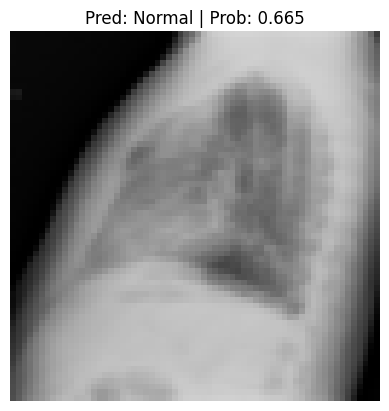

In [ ]:
# Pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device = device)

## Exercices